## Import necessary libraries and packages for preprocessing

In [1]:
import os
import mne
import joblib
import numpy as np
import os.path as op
import matplotlib.pyplot as plt
from mne.preprocessing import (ICA, corrmap, create_ecg_epochs, annotate_muscle_zscore, annotate_movement, 
                               compute_average_dev_head_t, create_eog_epochs, maxwell_filter, find_bad_channels_maxwell, 
                               maxwell_filter_prepare_emptyroom, find_eog_events, find_ecg_events)
from mne.chpi import (compute_chpi_amplitudes, compute_chpi_locs, compute_head_pos, write_head_pos)
#from mne.epochs import (average_movements)

## Load correct path to files and generate relative folders for outputs

In [ ]:
# Set pathway and doucment location
s = 'p0'
v = 'Final'
path = f'/Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro'
meg_dir = op.join(path, f'{s}_MEG_ENS_Gabor')

In [12]:
# Generate result folders
if not os.path.exists(op.join(meg_dir, v)):
    os.makedirs(op.join(meg_dir, v))

if not os.path.exists(op.join(meg_dir,v,'figures')):
    os.makedirs(op.join(meg_dir,v,'figures'))

if not os.path.exists(op.join(meg_dir,v,'Evoked')):
    os.makedirs(op.join(meg_dir,v,'Evoked'))

if not os.path.exists(op.join(meg_dir,v,'Source_Level')):
    os.makedirs(op.join(meg_dir,v,'Source_Level'))

In [5]:
def Crop_Raw_Boundary(raw_list, target_total_duration=None, boundary_threshold=2.0, make_divisible_by = 10):
    """
    Automatically crop MEG recordings based on trigger boundaries and duration requirements
    
    Parameters:
    raw_list : list; List of raw MEG objects [raw1, raw2, raw3, ...]
    boundary_threshold : Time threshold in seconds for cropping boundaries (default: 2.0)
    make_divisible_by : Make total duration divisible by this number (default: 10)
        
    Returns:
    cropped_raws : list
        List of cropped raw objects
    cropping_info : dict
        Information about the cropping process
    """
    # Store information about each recording
    recording_info = []
    cropped_raws = []
    boundary_threshold = 2
    make_divisible_by = 10
    
    # Step 1: Analyze each recording
    for i, raw in enumerate ([raw1, raw2, raw3, raw4, raw5, raw6, raw7, raw8], 1):
        # Find events
        events = mne.find_events(raw, stim_channel='STI101',shortest_event=1/raw.info['sfreq'])
        
        # Calculate timing information
        original_duration = raw.times[-1]  # Last time point
        original_tmin = raw.times[0]       # First time point (usually 0)
        original_tmax = raw.times[-1]      # Last time point
        
        # First and last trigger times (in seconds)
        First_trigger = (events[0, 0] - raw.first_samp) / raw.info['sfreq']
        Last_trigger = (events[-1, 0] - raw.first_samp) / raw.info['sfreq']
        
        # Calculate boundaries
        start_boundary = First_trigger - original_tmin
        end_boundary = original_tmax - Last_trigger
        
        # Determine cropping parameters
        crop_start = start_boundary > boundary_threshold
        crop_end = end_boundary > boundary_threshold
        
        # Calculate new tmin and tmax
        if crop_start:
            new_tmin = First_trigger - boundary_threshold
        else:
            new_tmin = original_tmin
            
        if crop_end:
            new_tmax = Last_trigger + boundary_threshold
        else:
            new_tmax = original_tmax
            
        new_duration = new_tmax - new_tmin
        
        # Store information
        info = {'recording_num': i,'original_duration': original_tmax,'original_tmin': original_tmin,'original_tmax': original_tmax,
                'first_trigger_time': First_trigger,'last_trigger_time': Last_trigger,'start_boundary': start_boundary,'end_boundary': end_boundary,
                'crop_start': crop_start,'crop_end': crop_end,'new_tmin': new_tmin,'new_tmax': new_tmax,'new_duration': new_duration,
                'time_saved': original_tmax - new_duration}
        recording_info.append(info)
        
        # Print analysis
        print(f"  Original duration: {original_tmax:.2f}s")
        print(f"  First trigger at: {First_trigger:.2f}s (boundary: {start_boundary:.2f}s)")
        print(f"  Last trigger at: {Last_trigger:.2f}s (boundary: {end_boundary:.2f}s)")
        # Decision logic
        if start_boundary <= boundary_threshold:
            print(f"  Start boundary ({start_boundary:.2f}s) <= threshold ({boundary_threshold}s): KEEPING original start")
        if end_boundary <= boundary_threshold:
            print(f"  End boundary ({end_boundary:.2f}s) <= threshold ({boundary_threshold}s): KEEPING original end")
            
        print(f"  Crop start: {crop_start} | Crop end: {crop_end}")
        print(f"  New duration: {new_duration:.2f}s (saved: {info['time_saved']:.2f}s)")
        print("="*60)
    
    # Step 2: Calculate total duration and adjust if needed
    total_original_duration = sum(info['original_duration'] for info in recording_info)
    total_new_duration = sum(info['new_duration'] for info in recording_info)

    print("Sum duration")
    print("="*40)
    print(f"Total original duration: {total_original_duration:.2f}s")
    print(f"Total new duration: {total_new_duration:.2f}s")
    #print(f"Total time saved: {total_original_duration - total_new_duration:.2f}s")

    # Step 3: Make duration divisible by target number
    if make_divisible_by:
        remainder = total_new_duration % make_divisible_by
        if remainder != 0:
            adjustment_needed = make_divisible_by - remainder
            print(f"\nAdjusting for divisibility by {make_divisible_by}:")
            print(f"  Current total: {total_new_duration:.2f}s")
            print(f"  Need to add: {adjustment_needed:.2f}s")
            
            # Distribute the adjustment across recordings that have room to extend
            adjustable_recordings = []
            for i, info in enumerate(recording_info):
                # Check if recording can be extended (has room at start or end)
                can_extend_start = info['new_tmin'] > info['original_tmin']
                can_extend_end = info['new_tmax'] < info['original_tmax']
                
                if can_extend_start or can_extend_end:
                    max_extension_start = info['new_tmin'] - info['original_tmin'] if can_extend_start else 0
                    max_extension_end = info['original_tmax'] - info['new_tmax'] if can_extend_end else 0
                    max_extension_total = max_extension_start + max_extension_end
                    
                    adjustable_recordings.append({'index': i,'info': info,
                        'can_extend_start': can_extend_start,'can_extend_end': can_extend_end,
                        'max_extension_start': max_extension_start,'max_extension_end': max_extension_end,'max_extension_total': max_extension_total})
            
            if adjustable_recordings:
                # Calculate total available extension
                total_available_extension = sum(rec['max_extension_total'] for rec in adjustable_recordings)
                
                if total_available_extension >= adjustment_needed:
                    print(f"  Available extension capacity: {total_available_extension:.2f}s")
                    
                    # Distribute adjustment proportionally
                    for rec in adjustable_recordings:
                        if rec['max_extension_total'] > 0:
                            proportion = rec['max_extension_total'] / total_available_extension
                            rec_adjustment = min(adjustment_needed * proportion, rec['max_extension_total'])
                            
                            # Decide where to add the time (prioritize end extension)
                            if rec['can_extend_end'] and rec['max_extension_end'] >= rec_adjustment:
                                rec['info']['new_tmax'] += rec_adjustment
                                print(f"    Recording {rec['info']['recording_num']}: extended end by {rec_adjustment:.2f}s")
                            elif rec['can_extend_start'] and rec['max_extension_start'] >= rec_adjustment:
                                rec['info']['new_tmin'] -= rec_adjustment
                                print(f"    Recording {rec['info']['recording_num']}: extended start by {rec_adjustment:.2f}s")
                            else:
                                # Split between start and end
                                end_ext = min(rec_adjustment / 2, rec['max_extension_end'])
                                start_ext = min(rec_adjustment - end_ext, rec['max_extension_start'])
                                
                                if end_ext > 0:
                                    rec['info']['new_tmax'] += end_ext
                                if start_ext > 0:
                                    rec['info']['new_tmin'] -= start_ext
                                
                                print(f"    Recording {rec['info']['recording_num']}: extended start by {start_ext:.2f}s, end by {end_ext:.2f}s")
                            
                            # Update duration
                            rec['info']['new_duration'] = rec['info']['new_tmax'] - rec['info']['new_tmin']
                    
                    # Recalculate total duration
                    total_new_duration = sum(info['new_duration'] for info in recording_info)
                    print(f"  New total duration: {total_new_duration:.2f}s")
                    print(f"  Divisible by {make_divisible_by}: {total_new_duration % make_divisible_by == 0}")
                    
                else:
                    print(f"  WARNING: Not enough extension capacity ({total_available_extension:.2f}s) for required adjustment ({adjustment_needed:.2f}s)")
                    print(f"  Will proceed with current duration (not divisible by {make_divisible_by})")
            else:
                print(f"  WARNING: No recordings can be extended to achieve divisibility")
                print(f"  All recordings are already at their original boundaries")
                print(f"  Will proceed with current duration (not divisible by {make_divisible_by})")
    
    # Step 4: Apply cropping
    print("APPLYING CROPPING")
    print("="*40)

    for i, (raw, info) in enumerate(zip([raw1, raw2, raw3, raw4, raw5, raw6, raw7, raw8], recording_info)):
        print(f"\nCropping Recording {info['recording_num']}...")
        print(f"  Cropping from {info['new_tmin']:.2f}s to {info['new_tmax']:.2f}s")
        try:
            # Create a copy and crop it
            raw_cropped = raw.copy()
            raw_cropped.crop(tmin=info['new_tmin'], tmax=info['new_tmax'])
            cropped_raws.append(raw_cropped)
            
            print(f"  ✓ Successfully cropped: {raw_cropped.times[-1]:.2f}s duration")
            
        except Exception as e:
            print(f"  ✗ Error cropping recording {info['recording_num']}: {e}")
            cropped_raws.append(raw)  # Keep original if cropping fails
    
    # Step 5: Final verification
    final_total_duration = sum(raw.times[-1] for raw in cropped_raws)

    print(f"\n" + "="*40)
    print("FINAL RESULTS")
    print("="*40)
    print(f"Number of recordings processed: {len(cropped_raws)}")
    print(f"Final total duration: {final_total_duration:.2f}s")
    print(f"Divisible by {make_divisible_by}: {final_total_duration % make_divisible_by == 0}")
    print(f"Total time saved: {total_original_duration - final_total_duration:.2f}s")

    # Create summary info
    cropping_info = {'total_original_duration': total_original_duration,
        'final_total_duration': final_total_duration,
        'time_saved': total_original_duration - final_total_duration,
        'recordings_info': recording_info,
        'boundary_threshold': boundary_threshold,
        'make_divisible_by': make_divisible_by,
        'is_divisible': final_total_duration % make_divisible_by == 0}
    
    return cropped_raws, cropping_info

print("✓ Function defined! Ready to use.")

✓ Function defined! Ready to use.


In [6]:
# Read in all raw MEG data (8 Blocks)
raw1 = mne.io.read_raw_fif(op.join(meg_dir,f'{s}_meg_ens_Gabor_01_raw.fif'), preload=True)
raw2 = mne.io.read_raw_fif(op.join(meg_dir,f'{s}_meg_ens_Gabor_02_raw.fif'), preload=True)
raw3 = mne.io.read_raw_fif(op.join(meg_dir,f'{s}_meg_ens_Gabor_03_raw.fif'), preload=True)
raw4 = mne.io.read_raw_fif(op.join(meg_dir,f'{s}_meg_ens_Gabor_04_raw.fif'), preload=True)
raw5 = mne.io.read_raw_fif(op.join(meg_dir,f'{s}_meg_ens_Gabor_05_raw.fif'), preload=True)
raw6 = mne.io.read_raw_fif(op.join(meg_dir,f'{s}_meg_ens_Gabor_06_raw.fif'), preload=True)
raw7 = mne.io.read_raw_fif(op.join(meg_dir,f'{s}_meg_ens_Gabor_07_raw.fif'), preload=True)
raw8 = mne.io.read_raw_fif(op.join(meg_dir,f'{s}_meg_ens_Gabor_08_raw.fif'), preload=True)
# Create the list
raw_list = [raw1, raw2, raw3, raw4, raw5, raw6, raw7, raw8]

Opening raw data file /Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro/p031_MEG_ENS_Gabor/p031_meg_ens_Gabor_01_raw.fif...
    Read a total of 13 projection items:
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
    Range : 20000 ... 425999 =     20.000 ...   425.999 secs
Ready.
Reading 0 ... 405999  =      0.000 ...   405.999 secs...
Opening raw data file /Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro/p031_ME

In [7]:
# Call the function (this executes all the cropping logic)
cropped_raws, cropping_info = Crop_Raw_Boundary(raw_list=raw_list,boundary_threshold=2.0, make_divisible_by=10)

# Start with first recording
raw_concatenated = cropped_raws[0].copy()

# Append each subsequent recording one by one
for raw_to_append in cropped_raws[1:]:
    raw_concatenated.append(raw_to_append)

237 events found on stim channel STI101
Event IDs: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 64]
  Original duration: 406.00s
  First trigger at: 10.61s (boundary: 10.61s)
  Last trigger at: 400.60s (boundary: 5.40s)
  Crop start: True | Crop end: True
  New duration: 393.99s (saved: 12.01s)
236 events found on stim channel STI101
Event IDs: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 64]
  Original duration: 402.00s
  First trigger at: 5.92s (boundary: 5.92s)
  Last trigger at: 395.48s (boundary: 6.52s)
  Crop start: True | Crop end: True
  New duration: 393.56s (saved: 8.44s)
235 events found on stim channel STI101
Event IDs: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 64]
  Original duration: 399.00s
  First trigger at: 3.48s (boundary: 3.48s)
  Last trigger at: 394.17s (boundary: 4.83s)
  Crop start: True | Crop end: True
  New duration: 394.69s (saved: 4.31s)
238 events found on stim channel STI101
Event IDs: [ 1  2  3 

In [8]:
# save new combined raw file
raw_concatenated.save(op.join(meg_dir,f'{s}_MEG_ENS_GABOR_raw.fif'), overwrite = True)

del raw1, raw2, raw3, raw4, raw5, raw6, raw7, raw8, raw_concatenated

Overwriting existing file.
Writing /Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro/p031_MEG_ENS_Gabor/p031_MEG_ENS_GABOR_raw.fif
Closing /Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro/p031_MEG_ENS_Gabor/p031_MEG_ENS_GABOR_raw.fif
Overwriting existing file.
Writing /Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro/p031_MEG_ENS_Gabor/p031_MEG_ENS_GABOR_raw-1.fif
Closing /Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro/p031_MEG_ENS_Gabor/p031_MEG_ENS_GABOR_raw-1.fif
[done]


# Read the appended raw file and Empty room data

In [6]:
# Load empty room data
raw_erm = mne.io.read_raw_fif(op.join(meg_dir, f'{s}_meg_ens_Gabor_erm_raw.fif'), preload=True)

# Load raw experimental data
raw = mne.io.Raw(op.join(meg_dir,f'{s}_MEG_ENS_GABOR_raw.fif'), preload=True)

Opening raw data file /Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro/p026_MEG_ENS_Gabor/p026_meg_ens_Gabor_erm_raw.fif...
    Read a total of 13 projection items:
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
    Range : 3000 ... 330999 =      3.000 ...   330.999 secs
Ready.
Reading 0 ... 327999  =      0.000 ...   327.999 secs...
Opening raw data file /Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro/p026_ME

## Visualize MEG channels by interactive windows & Power Spectral Density

In [10]:
# Use this command to visualise interactive plot, "raw.info" will show some infromation 
%matplotlib qt
raw.copy().filter(l_freq=1, h_freq=80).plot(n_channels = 25)  # Change n_channels can adjust the size 

#record bad channels here, you will add them at a later step!!!!!!!!!
# Raw PSD Plot
fig1 = raw.compute_psd(fmin=1,fmax=100, n_fft=1000).plot()
fig1.suptitle('Raw PSD Plot')
plt.show()
fig1.savefig(op.join(meg_dir,v,'figures', f'{s}_GABOR_raw_psd'))
# Empty Room PSD Plot
fig2 = raw_erm.compute_psd(fmin=1,fmax=100, n_fft=1000).plot()
fig2.suptitle('Raw empty room PSD Plot')
plt.show()
fig2.savefig(op.join(meg_dir,v,'figures', f'{s}_GABOR_erm_raw_psd'))

Filtering raw data in 8 contiguous segments
Setting up band-pass filter from 1 - 80 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 80.00 Hz
- Upper transition bandwidth: 20.00 Hz (-6 dB cutoff frequency: 90.00 Hz)
- Filter length: 3301 samples (3.301 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    1.5s
[Parallel(n_jobs=1)]: Done 306 out of 306 | elapsed:    1.6s finished


Using matplotlib as 2D backend.
Effective window size : 1.000 (s)
Plotting power spectral density (dB=True).
Effective window size : 1.000 (s)
Plotting power spectral density (dB=True).


Channels marked as bad:
none


## Begin preprocessing here

In [7]:
# Set to True if headpos has not already been calculated & saved
calc_headpos = True

# Other parameters
lpval = 1    # Low-frequency band is 1 Hz
hpval = 80   # High-frquency band is 80 Hz

# For kid, 6 and .98; For adults, 10 and .99/98
tsss_dur = 10
tsss_cor = .99

# read in system specific cross-talk and fine calibration files 
Crosstalk = op.join(path, 'ct_sparse.fif')
Fine_calibration = op.join(path, 'sss_cal.dat')

In [8]:
# Calculate data duration
raw_duration = raw.times[-1] 
print("duration of raw data:", raw_duration)
erm_duration = raw_erm.times[-1] 
print("duration of raw erm data:", erm_duration)

duration of raw data: 3140.008
duration of raw erm data: 327.999


In [9]:
# Crop data such that it is divisible by tsss_dur (10)
raw.crop(tmax=3140)
raw_erm.crop(tmax=320)

<Raw | p026_meg_ens_Gabor_erm_raw.fif, 329 x 320001 (320.0 s), ~804.0 MiB, data loaded>

In [10]:
#check if data has been cropped
raw_duration = raw.times[-1] 
print("duration of raw data:", raw_duration)
erm_duration = raw_erm.times[-1] 
print("duration of raw erm data:", erm_duration)

duration of raw data: 3140.0
duration of raw erm data: 320.0


## Compute time varying head position indicator (cHPI) amplitudes

In [11]:
# setup for movement compensation by extracting coil info (perform on unfiltered raw)
if calc_headpos == True:
    amps = compute_chpi_amplitudes(raw)
    locs = compute_chpi_locs(raw.info, amps)
    pos = compute_head_pos(raw.info, locs, verbose = True)  #, gof_limit=0.9) 
    # save pos file (computing takes awhile)
    write_head_pos(op.join(meg_dir,v, f'{s}_GABOR_all_pos.fif'), pos)
else:
    pos = mne.chpi.read_head_pos(op.join(meg_dir,v, f'{s}_GABOR_all_pos.fif'))
    
# get initial head position and calculate average position (across time)
orig_head_dev_t = mne.transforms.invert_transform(raw.info["dev_head_t"])
avg_head_dev_t = mne.transforms.invert_transform(compute_average_dev_head_t(raw, pos))

fig = mne.viz.plot_head_positions(pos)
for ax, val, val_ori in zip(
    fig.axes[::2],
    avg_head_dev_t["trans"][:3, 3],
    orig_head_dev_t["trans"][:3, 3],
):
    ax.axhline(1000 * val, color="r")
    ax.axhline(1000 * val_ori, color="g")
fig.savefig(op.join(meg_dir,v,'figures', f'{s}_GABOR_all_headpos'))

# use average position for movement compensation destination    
destination = (raw.info['dev_head_t']['trans'][:3, 3]) # specifies which head file to use. 

Using 5 HPI coils: 293 307 314 321 328 Hz
Line interference frequencies: 60.0 120.0 180.0 240.0 300.0 Hz
Using time window: 142.9 ms
Fitting 5 HPI coil locations at up to 313993 time points (3140.0 s duration)


  0%|          | cHPI amplitudes : 0/313993 [00:00<?,       ?it/s]

Computing 4385 HPI location guesses (1 cm grid in a 10.7 cm sphere)
HPIFIT: 5 coils digitized in order 5 2 1 4 3
HPI consistency of isotrak and hpifit is OK.


  0%|          | cHPI locations  : 0/313993 [00:00<?,       ?it/s]

    t=17.110:    4/5 good HPI fits, movements [mm/s] =      0.1 /      0.1 /      0.4 /      0.1 /      0.1
    t=18.110:    4/5 good HPI fits, movements [mm/s] =      0.1 /      0.3 /      0.1 /      0.2 /      0.4
    t=19.110:    4/5 good HPI fits, movements [mm/s] =      0.5 /      0.8 /      0.4 /      0.7 /      1.0
    t=20.110:    4/5 good HPI fits, movements [mm/s] =      0.8 /      0.5 /      0.6 /      0.7 /      0.7
    t=21.110:    4/5 good HPI fits, movements [mm/s] =      0.4 /      0.3 /      0.2 /      0.4 /      0.4
    t=22.110:    4/5 good HPI fits, movements [mm/s] =      0.1 /      0.2 /      0.3 /      0.3 /      0.3
    t=23.110:    4/5 good HPI fits, movements [mm/s] =      0.1 /      0.3 /      0.1 /      0.2 /      0.6
    t=24.110:    4/5 good HPI fits, movements [mm/s] =      0.1 /      0.2 /      0.0 /      0.1 /      0.1
    t=25.110:    4/5 good HPI fits, movements [mm/s] =      0.1 /      0.1 /      0.0 /      0.0 /      0.1
    t=26.110:    4/5 good HP

...

/var/folders/wy/8whx0tpj43sgygf2n0g0f5340000gn/T/ipykernel_17811/901128386.py:5: RuntimeWarning:     t=2374.140:  2/5 good HPI fits, cannot determine the transformation (1.00, 0.58, 1.00, 0.69, 0.93 GOF)!
  pos = compute_head_pos(raw.info, locs, verbose = True)  #, gof_limit=0.9)
/var/folders/wy/8whx0tpj43sgygf2n0g0f5340000gn/T/ipykernel_17811/901128386.py:5: RuntimeWarning:     t=2374.150:  1/5 good HPI fits, cannot determine the transformation (1.00, 0.84, 0.87, 0.80, 0.79 GOF)!
  pos = compute_head_pos(raw.info, locs, verbose = True)  #, gof_limit=0.9)
/var/folders/wy/8whx0tpj43sgygf2n0g0f5340000gn/T/ipykernel_17811/901128386.py:5: RuntimeWarning:     t=2374.160:  1/5 good HPI fits, cannot determine the transformation (1.00, 0.92, 0.86, 0.62, 0.56 GOF)!
  pos = compute_head_pos(raw.info, locs, verbose = True)  #, gof_limit=0.9)
/var/folders/wy/8whx0tpj43sgygf2n0g0f5340000gn/T/ipykernel_17811/901128386.py:5: RuntimeWarning:     t=2374.170:  1/5 good HPI fits, cannot determine the tra

    t=2452.270:  4/5 good HPI fits, movements [mm/s] =      0.0 /      0.2 /      0.0 /      0.2 /      0.2
    t=2453.270:  4/5 good HPI fits, movements [mm/s] =      0.1 /      0.4 /      0.1 /      0.6 /      0.3
    t=2454.270:  4/5 good HPI fits, movements [mm/s] =      0.1 /      0.2 /      0.0 /      0.3 /      0.3
    t=2455.270:  3/5 good HPI fits, movements [mm/s] =      0.1 /      0.0 /      0.0 /      0.2 /      0.2
    t=2456.270:  4/5 good HPI fits, movements [mm/s] =      0.0 /      0.3 /      0.0 /      0.2 /      0.2
    t=2457.270:  4/5 good HPI fits, movements [mm/s] =      0.1 /      0.6 /      0.1 /      0.5 /      0.4
    t=2458.270:  4/5 good HPI fits, movements [mm/s] =      0.0 /      0.2 /      0.1 /      0.1 /      0.1
    t=2459.270:  4/5 good HPI fits, movements [mm/s] =      0.1 /      0.1 /      0.1 /      0.3 /      0.1
    t=2460.270:  4/5 good HPI fits, movements [mm/s] =      0.0 /      0.2 /      0.1 /      0.1 /      0.3
    t=2461.270:  4/5 good HP

/var/folders/wy/8whx0tpj43sgygf2n0g0f5340000gn/T/ipykernel_17811/901128386.py:5: RuntimeWarning:     t=2765.630:  2/5 good HPI fits, cannot determine the transformation (1.00, 0.98, 0.98, 0.96, 0.67 GOF)!
  pos = compute_head_pos(raw.info, locs, verbose = True)  #, gof_limit=0.9)
/var/folders/wy/8whx0tpj43sgygf2n0g0f5340000gn/T/ipykernel_17811/901128386.py:5: RuntimeWarning:     t=2765.640:  2/5 good HPI fits, cannot determine the transformation (1.00, 0.70, 0.99, 0.64, 0.52 GOF)!
  pos = compute_head_pos(raw.info, locs, verbose = True)  #, gof_limit=0.9)
/var/folders/wy/8whx0tpj43sgygf2n0g0f5340000gn/T/ipykernel_17811/901128386.py:5: RuntimeWarning:     t=2765.650:  1/5 good HPI fits, cannot determine the transformation (1.00, 0.75, 0.89, 0.89, 0.95 GOF)!
  pos = compute_head_pos(raw.info, locs, verbose = True)  #, gof_limit=0.9)
/var/folders/wy/8whx0tpj43sgygf2n0g0f5340000gn/T/ipykernel_17811/901128386.py:5: RuntimeWarning:     t=2765.670:  2/5 good HPI fits, cannot determine the tra

    t=2838.770:  4/5 good HPI fits, movements [mm/s] =      0.1 /      0.2 /      0.1 /      0.2 /      0.2
    t=2839.770:  4/5 good HPI fits, movements [mm/s] =      0.1 /      0.2 /      0.1 /      0.3 /      0.2
    t=2840.770:  4/5 good HPI fits, movements [mm/s] =      0.1 /      0.2 /      0.0 /      0.3 /      0.2
    t=2841.770:  4/5 good HPI fits, movements [mm/s] =      0.1 /      0.2 /      0.1 /      0.1 /      0.2
    t=2842.770:  4/5 good HPI fits, movements [mm/s] =      0.2 /      0.1 /      0.1 /      0.2 /      0.3
    t=2843.770:  4/5 good HPI fits, movements [mm/s] =      0.1 /      0.1 /      0.1 /      0.3 /      0.3
    t=2844.770:  3/5 good HPI fits, movements [mm/s] =      0.2 /      0.3 /      0.2 /      0.5 /      0.5
    t=2845.770:  4/5 good HPI fits, movements [mm/s] =      0.1 /      0.1 /      0.1 /      0.2 /      0.2
    t=2846.770:  4/5 good HPI fits, movements [mm/s] =      0.1 /      0.0 /      0.1 /      0.3 /      0.2
    t=2847.770:  4/5 good HP

FileNotFoundError: [Errno 2] No such file or directory: '/Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro/p026_MEG_ENS_Gabor/Final/p026_GABOR_all_pos.fif'

## Remove power line noisy (60Hz), via Notch filter

In [16]:
# Filter out cHPI signals first
#raw_cHPI = raw.copy()
#mne.chpi.filter_chpi(raw_cHPI) 

# Remove power line noise (60 Hz for US and Canada)
raw_Notch = raw.copy()
raw_erm_Notch = raw_erm.copy()
raw_Notch.notch_filter(freqs = 60, fir_design='firwin')   #mt_bandwidth = 4  method='spectrum_fit',
raw_erm_Notch.notch_filter(freqs = 60, fir_design='firwin')  # mt_bandwidth = 4,  method='spectrum_fit',

# We will use Notch filtered data next, delete previous data to save storage
del raw, raw_erm

# Visualize the power spectral density 
EMM = raw_Notch.compute_psd(fmin=1, fmax=90, n_fft=1000, picks='meg').plot()
EMM.suptitle('Raw Notch (60Hz) only, no eSSS')
EMM.savefig(op.join(meg_dir,v,'figures', f'{s}_Raw_Notch_Filtered_60Hz'))

EMMMM = raw_erm_Notch.compute_psd(fmin=1, fmax=90, n_fft=1000, picks='meg').plot()
EMMMM.suptitle('Empty Room Notch (60Hz) only, no eSSS')
EMMMM.savefig(op.join(meg_dir,v,'figures', f'{s}_Raw_Empty_Room_Notch_Filtered_60Hz'))

Filtering raw data in 8 contiguous segments
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 6601 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    1.1s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    1.8s
[Parallel(n_jobs=1)]: Done 306 out of 306 | elapsed:    2.0s finished


Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 6601 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    1.7s
[Parallel(n_jobs=1)]: Done 306 out of 306 | elapsed:    1.8s finished


Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 6601 samples (6.601 s)



...

Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 6601 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    1.6s
[Parallel(n_jobs=1)]: Done 306 out of 306 | elapsed:    1.6s finished


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 6601 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.7s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    1.2s
[Parallel(n_jobs=1)]: Done 306 out of 306 | elapsed:    1.3s finished


Effective window size : 1.000 (s)
Plotting power spectral density (dB=True).
Effective window size : 1.000 (s)
Plotting power spectral density (dB=True).


In [25]:
# Just in case, if you cannot finish entire perprocessing once. 
#raw_Notch.save(op.join(meg_dir,f'{s}_Raw_Notch_raw.fif'),overwrite = True)
#raw_erm_Notch.save(op.join(meg_dir,f'{s}_Raw_Empty_Notch_raw.fif'),overwrite = True)

# Read raw nothced files
# raw_Notch = mne.io.read_raw_fif(op.join(meg_dir, f'{s}_Raw_Notch_raw.fif'), preload=True)
# raw_erm_Notch = mne.io.read_raw_fif(op.join(meg_dir, f'{s}_Raw_Empty_Notch_raw.fif'), preload=True)

## Bad Channels Detection

Applying low-pass filter with 80 Hz cutoff frequency ...
Filtering raw data in 8 contiguous segments
Setting up low-pass filter at 80 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 80.00 Hz
- Upper transition bandwidth: 20.00 Hz (-6 dB cutoff frequency: 90.00 Hz)
- Filter length: 165 samples (0.165 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    2.0s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    3.1s
[Parallel(n_jobs=1)]: Done 306 out of 306 | elapsed:    3.2s finished


Scanning for bad channels in 630 intervals (5.0 s) ...
102 of 102 magnetometer types replaced with T3.
    No bad MEG channels
    Processing 204 gradiometers and 102 magnetometers
    Using fine calibration sss_cal.dat
        Adjusting non-orthogonal EX and EY
        Adjusted coil orientations by (μ ± σ): 0.4° ± 0.3° (max: 1.4°)
    Automatic origin fit: head of radius 85.8 mm
    Using origin 2.6, 5.1, 47.0 mm in the head frame
        Interval   1:    0.000 -    4.999
        Interval   2:    5.000 -    9.999
        Interval   3:   10.000 -   14.999
        Interval   4:   15.000 -   19.999
        Interval   5:   20.000 -   24.999
        Interval   6:   25.000 -   29.999
        Interval   7:   30.000 -   34.999
        Interval   8:   35.000 -   39.999
        Interval   9:   40.000 -   44.999
        Interval  10:   45.000 -   49.999
        Interval  11:   50.000 -   54.999
        Interval  12:   55.000 -   59.999
        Interval  13:   60.000 -   64.999
        Interval  

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    1.7s
[Parallel(n_jobs=1)]: Done 306 out of 306 | elapsed:    1.8s finished


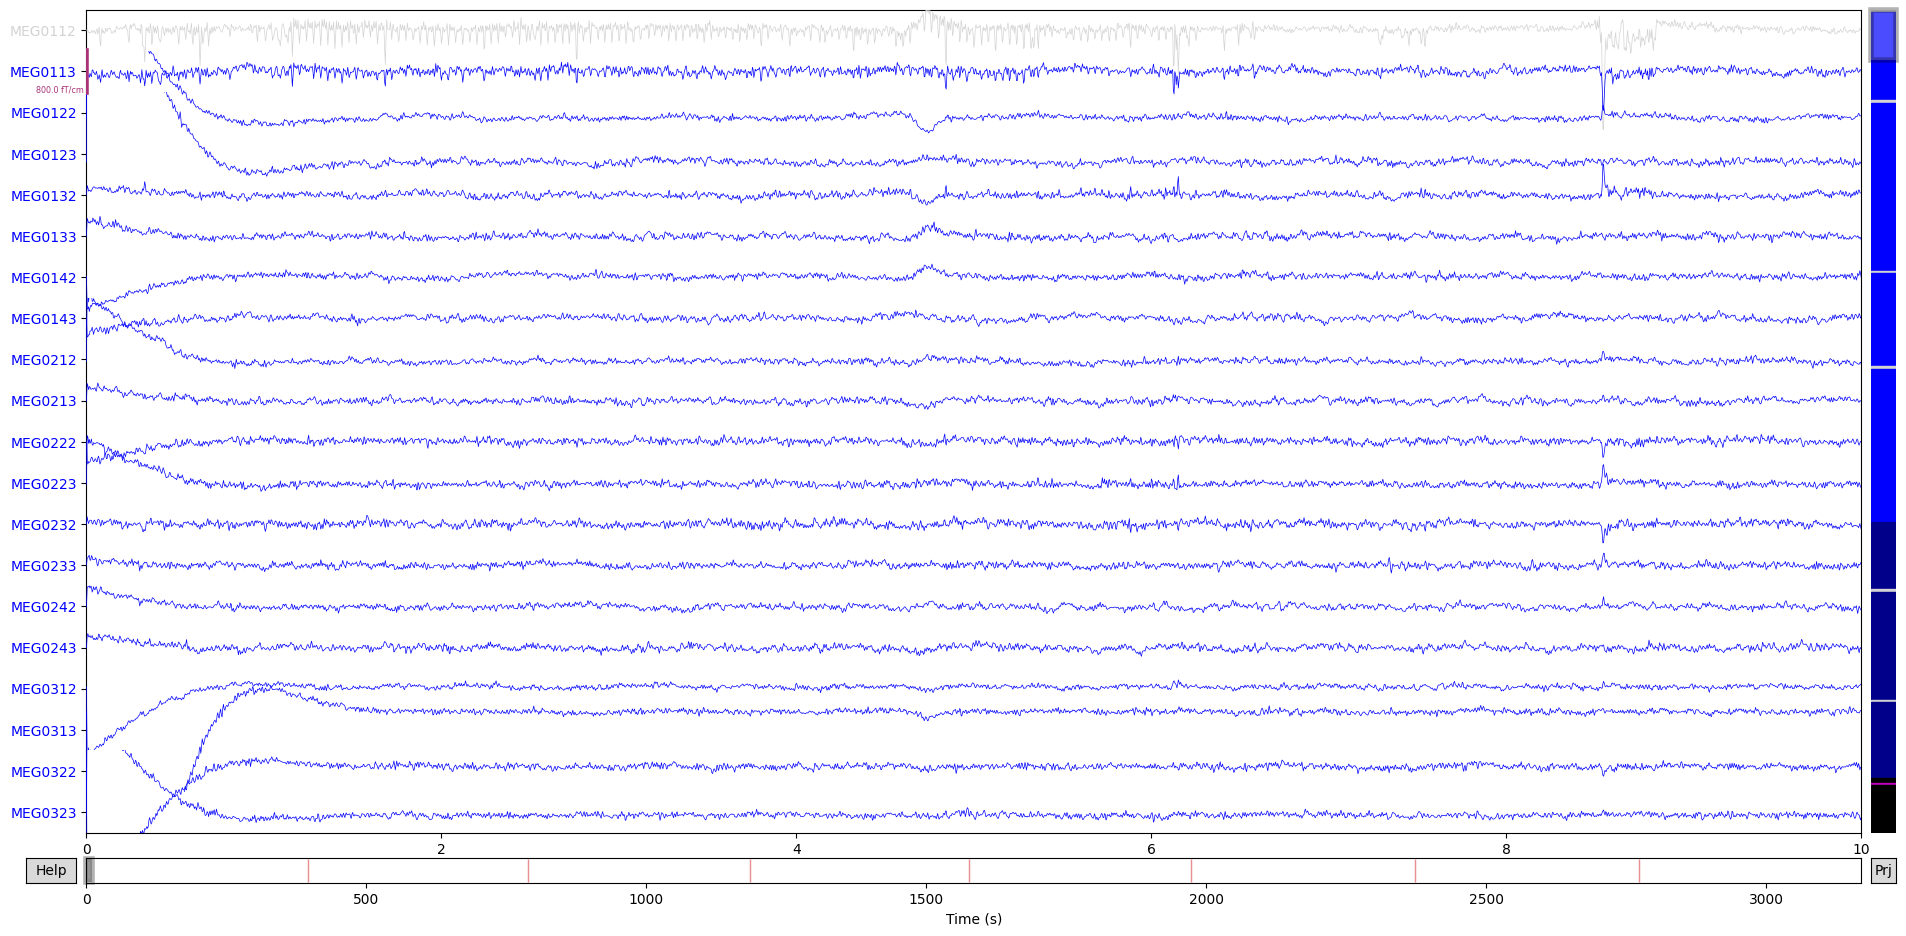

In [24]:
# Bad channel detection, Automated bad channels detector
raw_Notch.info['bads'] = []
raw_check = raw_Notch.copy()
auto_noisy_chs, auto_flat_chs, auto_scores = find_bad_channels_maxwell(raw_check, cross_talk = Crosstalk, calibration = Fine_calibration,
                                                                       head_pos=pos, return_scores=True, verbose=True, h_freq = hpval) # Change to 80 for now
#auto_noisy_chs: Automatically Detected Noisy Channels
# auto_flat_chs: Automatically Detected Flat Channels
# auto_scores: Detailed Channel Quality Scores)

# Combine all bad channels
bads = raw_check.info['bads'] + auto_noisy_chs + auto_flat_chs
raw_Notch.info['bads'] = bads

# Print the results (All bad channels)
print("noisy channels: ", ' '.join(auto_noisy_chs))
print("Flat channels: ", ' '.join(auto_flat_chs))
print("All bad channels: ", ' '.join(bads))

# Visualize bad channels, depends on you
raw_chan = raw_Notch.copy().filter(l_freq=lpval, h_freq=hpval, fir_design='firwin', phase='zero')
raw_chan.plot()

In [17]:
# Add bad channels here, normal bad channels and BAD CHANNELS HERE AFTER VISUAL INSPECTION TOO
All_Bad_Channels = raw_Notch.info['bads'] + ['MEG1213', 'MEG2122', 'MEG0112', 'MEG0113', 'MEG0423', 'MEG0532','MEG1243', 'MEG2213']
raw_Notch.info['bads'] = All_Bad_Channels
raw_erm_Notch.info['bads'] = raw_Notch.info['bads']

#check if all bads have been added
print(raw_Notch.info['bads'])
print(raw_erm_Notch.info['bads'])

['MEG1213', 'MEG2122', 'MEG0112', 'MEG0113', 'MEG0423', 'MEG0532', 'MEG1243', 'MEG2213']
['MEG1213', 'MEG2122', 'MEG0112', 'MEG0113', 'MEG0423', 'MEG0532', 'MEG1243', 'MEG2213']


In [18]:
# Band-pass Filter on both Raw and empty room data
raw_filtered = raw_Notch.copy().filter(l_freq=lpval, h_freq=hpval,fir_design='firwin',phase='zero') 
erm_filtered = raw_erm_Notch.copy().filter(l_freq=lpval, h_freq=hpval,fir_design='firwin',phase='zero') 

#check if all bads have been added in filtered as well
print(raw_filtered.info['bads'])
print(erm_filtered.info['bads'])

Filtering raw data in 8 contiguous segments
Setting up band-pass filter from 1 - 80 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 80.00 Hz
- Upper transition bandwidth: 20.00 Hz (-6 dB cutoff frequency: 90.00 Hz)
- Filter length: 3301 samples (3.301 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    1.4s
[Parallel(n_jobs=1)]: Done 306 out of 306 | elapsed:    1.5s finished


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 80 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 80.00 Hz
- Upper transition bandwidth: 20.00 Hz (-6 dB cutoff frequency: 90.00 Hz)
- Filter length: 3301 samples (3.301 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.9s


['MEG1213', 'MEG2122', 'MEG0112', 'MEG0113', 'MEG0423', 'MEG0532', 'MEG1243', 'MEG2213']
['MEG1213', 'MEG2122', 'MEG0112', 'MEG0113', 'MEG0423', 'MEG0532', 'MEG1243', 'MEG2213']


[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    1.4s
[Parallel(n_jobs=1)]: Done 306 out of 306 | elapsed:    1.5s finished


In [ ]:
# Double Check the projectors
Filtered = erm_filtered.compute_psd(fmin=1, fmax=90, n_fft=1000, picks='meg').plot()
Filtered.suptitle('Filtered Empty Room Data from Projectors')
Filtered_raw = raw_filtered.compute_psd(fmin=1, fmax=90, n_fft=1000, picks='meg').plot()
Filtered_raw.suptitle('Filtered Raw Data from Projectors')

Effective window size : 1.000 (s)
Plotting power spectral density (dB=True).
Effective window size : 1.000 (s)


In [30]:
#find freq ranges to use for projections
erm1 = raw_erm_Notch.copy().filter(l_freq=8, h_freq=11)
erm2 = raw_erm_Notch.copy().filter(l_freq=20, h_freq=22)
erm3 = raw_erm_Notch.copy().filter(l_freq=28, h_freq=31)
erm4 = raw_erm_Notch.copy().filter(l_freq=39, h_freq=45)
erm5 = raw_erm_Notch.copy().filter(l_freq=45, h_freq=53) # Including power_line noisy. 
erm6 = raw_erm_Notch.copy().filter(l_freq=56, h_freq=59)
#erm7 = raw_erm_Notch.copy().filter(l_freq=71, h_freq=73)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 11 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 11.00 Hz
- Upper transition bandwidth: 2.75 Hz (-6 dB cutoff frequency: 12.38 Hz)
- Filter length: 1651 samples (1.651 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.6s


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 20 - 22 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 20.00


[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done 306 out of 306 | elapsed:    1.1s finished


- Lower transition bandwidth: 5.00 Hz (-6 dB cutoff frequency: 17.50 Hz)
- Upper passband edge: 22.00 Hz
- Upper transition bandwidth: 5.50 Hz (-6 dB cutoff frequency: 24.75 Hz)
- Filter length: 661 samples (0.661 s)



...

[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done 306 out of 306 | elapsed:    1.1s finished
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.8s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done 306 out of 306 | elapsed:    1.4s finished


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 45 - 53 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 45.00
- Lower transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 39.38 Hz)
- Upper passband edge: 53.00 Hz
- Upper transition bandwidth: 13.25 Hz (-6 dB cutoff frequency: 59.62 Hz)
- Filter length: 295 samples (0.295 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.7s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done 306 out of 306 | elapsed:    1.4s finished


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 56 - 59 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 56.00
- Lower transition bandwidth: 14.00 Hz (-6 dB cutoff frequency: 49.00 Hz)
- Upper passband edge: 59.00 Hz
- Upper transition bandwidth: 14.75 Hz (-6 dB cutoff frequency: 66.38 Hz)
- Filter length: 237 samples (0.237 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.7s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done 306 out of 306 | elapsed:    1.3s finished


In [31]:
# Here we will bandapss the empty-room data around the vibration artifacts, compute erm projectors from empty-room to use for eSSS
erm_proj1 = mne.compute_proj_raw(erm1, meg='combined')
erm_proj2 = mne.compute_proj_raw(erm2, meg='combined')
erm_proj3 = mne.compute_proj_raw(erm3, meg='combined')
erm_proj4 = mne.compute_proj_raw(erm4, meg='combined')
erm_proj5 = mne.compute_proj_raw(erm5, meg='combined')
erm_proj6 = mne.compute_proj_raw(erm6, meg='combined')
#erm_proj7 = mne.compute_proj_raw(erm7, meg='combined')

erm_projectors = erm_proj1 + erm_proj2 + erm_proj3 + erm_proj4 + erm_proj5 + erm_proj6 #+ erm_proj7
  
# print("all bad channels: " + ' '.join(raw_Notch.info['bads']))
# print("empty room bad channels: " + ' '.join(raw_erm.info['bads']))

# Plot the combined projectors
Projection_figure = mne.viz.plot_projs_topomap(erm_projectors, colorbar=True, info=raw_filtered.info)
Projection_figure.savefig(op.join(meg_dir,v,'figures', f'{s}_Projection_topography'))

# Prepare empty room for Maxwell filtering
erm_maxwell_prepare = maxwell_filter_prepare_emptyroom(erm_filtered, raw=raw_filtered)

Not setting metadata
300 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 13)


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.2s


Dropped 0/300 epochs
Adding projection: meg-Raw-0.000-300.001-PCA-01 (exp var=1.8%)
Adding projection: meg-Raw-0.000-300.001-PCA-02 (exp var=1.7%)
No channels 'eeg' found. Skipping.
Not setting metadata
300 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 13)


[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.1s


Dropped 0/300 epochs
Adding projection: meg-Raw-0.000-300.001-PCA-01 (exp var=7.2%)
Adding projection: meg-Raw-0.000-300.001-PCA-02 (exp var=3.0%)
No channels 'eeg' found. Skipping.
Not setting metadata
300 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 13)


...

[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.1s


Dropped 0/300 epochs
Adding projection: meg-Raw-0.000-300.001-PCA-01 (exp var=10.0%)
Adding projection: meg-Raw-0.000-300.001-PCA-02 (exp var=3.8%)
No channels 'eeg' found. Skipping.
Not setting metadata
300 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 13)


[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.2s


Dropped 0/300 epochs
Adding projection: meg-Raw-0.000-300.001-PCA-01 (exp var=7.1%)
Adding projection: meg-Raw-0.000-300.001-PCA-02 (exp var=5.4%)
No channels 'eeg' found. Skipping.


[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    0.3s finished


## Signal-Space Separation

In [32]:
# perform eSSS on filtered data
raw_esss = maxwell_filter(raw_filtered, calibration=Fine_calibration, cross_talk=Crosstalk, st_duration=10, bad_condition="ignore", extended_proj=erm_projectors, st_correlation=0.99, head_pos=pos, destination=destination, verbose=True)

erm_esss = maxwell_filter(erm_maxwell_prepare, calibration=Fine_calibration, cross_talk=Crosstalk, st_duration=10, extended_proj=erm_projectors, st_correlation=0.99, coord_frame="meg", verbose=True)

Maxwell filtering raw data
102 of 102 magnetometer types replaced with T3.
    Bad MEG channels being reconstructed: ['MEG0741', 'MEG0812', 'MEG0912', 'MEG1921', 'MEG1922', 'MEG0423', 'MEG0932', 'MEG1132', 'MEG1213', 'MEG2122', 'MEG2213']
    Processing 204 gradiometers and 102 magnetometers
    Extending external SSS basis using 12 projection vectors
    Using fine calibration sss_cal.dat
        Adjusting non-orthogonal EX and EY
        Adjusted coil orientations by (μ ± σ): 0.4° ± 0.3° (max: 1.4°)
    Automatic origin fit: head of radius 80.4 mm
    Using origin 2.7, 8.7, 54.9 mm in the head frame
    Processing data using tSSS with st_duration=10.0
        Using 96/107 harmonic components for    0.000  (69/80 in, 27/27 out)
    Appending head position result channels and copying original raw data
    Spatiotemporal window did not fit evenly intocontiguous data segment. 1.08 seconds were lumped into the previous window.
    Spatiotemporal window did not fit evenly intocontiguous da

/var/folders/wy/8whx0tpj43sgygf2n0g0f5340000gn/T/ipykernel_27643/4211499167.py:2: RuntimeWarning: SVD error (SVD did not converge), attempting to use GESVD instead of GESDD
  raw_esss = maxwell_filter(raw_filtered, calibration=Fine_calibration, cross_talk=Crosstalk, st_duration=10, bad_condition="ignore", extended_proj=erm_projectors, st_correlation=0.99, head_pos=pos, destination=destination, verbose=True)


        Using 99/107 harmonic components for  240.999  (72/80 in, 27/27 out)
        Using 97/107 harmonic components for  241.999  (70/80 in, 27/27 out)
        Using 97/107 harmonic components for  242.999  (70/80 in, 27/27 out)
        Using 97/107 harmonic components for  243.999  (70/80 in, 27/27 out)
        Using 97/107 harmonic components for  244.999  (70/80 in, 27/27 out)
        Using 97/107 harmonic components for  245.999  (70/80 in, 27/27 out)
        Using 97/107 harmonic components for  246.999  (70/80 in, 27/27 out)
        Using 97/107 harmonic components for  247.999  (70/80 in, 27/27 out)
        Using 97/107 harmonic components for  248.999  (70/80 in, 27/27 out)
        Using 97/107 harmonic components for  249.999  (70/80 in, 27/27 out)
        Using 98/107 harmonic components for  250.000  (71/80 in, 27/27 out)
        Projecting  0 intersecting tSSS components for  250.000 -  259.999 s  (#26/312) (across 11 positions)
        Using 97/107 harmonic components fo

## Covariance matrix on downsampled empty room data from ML and Frequency analysis

In [33]:
# Downsample empty room data to 500Hz
erm_500Hz =erm_esss.copy().resample(500, npad ='auto')
# Estimate noise covariance matrix from a continuous segment of raw data. 
noise_cov = mne.compute_raw_covariance(erm_500Hz, tmin=0, tmax=None)

# Generate path and name for empty room covariance  # Ask Minsu why he saved filter_ica, ica whole in empty room!!!!
mne.write_cov(op.join(meg_dir,v, f'{s}_erm-cov.fif'), noise_cov, overwrite=True)

# Plot the covariance martix and eigenvalue index, rank estimation tells you how many independent signal components exist in your data.
fig_cov, fig_spectra = noise_cov.plot(erm_500Hz.info, proj=True)

# Save the covariance matrix figure
fig_cov.savefig(op.join(meg_dir, v, 'figures', f'{s}_empty_covariance_matrix.png'), dpi=300)
# Save the eigenvalue spectra figure
fig_spectra.savefig(op.join(meg_dir, v, 'figures', f'{s}_empty_covariance_spectra.png'), dpi=300)

Using up to 1500 segments
Number of samples used : 150000
[done]
Overwriting existing file.
    The projection vectors do not apply to these channels.
Computing rank from covariance with rank=None
    Using tolerance 3e-15 (2.2e-16 eps * 102 dim * 0.13  max singular value)
    Estimated rank (mag): 73
    MAG: rank 73 computed from 102 data channels with 0 projectors
Computing rank from covariance with rank=None
    Using tolerance 6.9e-14 (2.2e-16 eps * 204 dim * 1.5  max singular value)
    Estimated rank (grad): 73
    GRAD: rank 73 computed from 204 data channels with 0 projectors


In [37]:
# plot tSSS and eSSS spectra to ensure the artifact is suppressed
fig_eSSS = raw_esss.compute_psd(fmin=1,fmax=90).plot()
fig_eSSS.suptitle('Raw eSSS PSD Plot')
fig_eSSS.savefig(op.join(meg_dir,v,'figures', f'{s}_Final_GABOR_Raw_esss_psd'))
plt.show()

fig_erm_eSSS = erm_esss.compute_psd(fmin=1,fmax=90).plot()
fig_erm_eSSS.suptitle('Empty Room eSSS PSD Plot')
fig_erm_eSSS.savefig(op.join(meg_dir,v,'figures', f'{s}_Final_GABOR_Empty_Room_esss_psd'))
plt.show()

Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).
Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


In [35]:
# # Head movement annotation
# annotation_movement, hpi_disp = annotate_movement(raw_esss, pos, mean_distance_limit=0.05)
# raw_esss.set_annotations(annotation_movement)
# raw_esss.plot(n_channels=100, duration=20)

In [36]:
# Saving external signal space separation filtered file
raw_esss.save(op.join(meg_dir,v, f'{s}_GABOR_all_esss.fif'), overwrite = True)

erm_esss.save(op.join(meg_dir,v, f'{s}_GABOR_erm_esss.fif'), overwrite = True)

Overwriting existing file.
Writing /Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro/p024_MEG_ENS_Gabor/Final/p024_GABOR_all_esss.fif


/var/folders/wy/8whx0tpj43sgygf2n0g0f5340000gn/T/ipykernel_27643/3527326854.py:2: RuntimeWarning: This filename (/Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro/p024_MEG_ENS_Gabor/Final/p024_GABOR_all_esss.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_esss.save(op.join(meg_dir,v, f'{s}_GABOR_all_esss.fif'), overwrite = True)


Closing /Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro/p024_MEG_ENS_Gabor/Final/p024_GABOR_all_esss.fif
Overwriting existing file.
Writing /Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro/p024_MEG_ENS_Gabor/Final/p024_GABOR_all_esss-1.fif
Closing /Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro/p024_MEG_ENS_Gabor/Final/p024_GABOR_all_esss-1.fif
[done]
Overwriting existing file.
Writing /Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro/p024_MEG_ENS_Gabor/Final/p024_GABOR_erm_esss.fif


/var/folders/wy/8whx0tpj43sgygf2n0g0f5340000gn/T/ipykernel_27643/3527326854.py:4: RuntimeWarning: This filename (/Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro/p024_MEG_ENS_Gabor/Final/p024_GABOR_erm_esss.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  erm_esss.save(op.join(meg_dir,v, f'{s}_GABOR_erm_esss.fif'), overwrite = True)


Closing /Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro/p024_MEG_ENS_Gabor/Final/p024_GABOR_erm_esss.fif
[done]


[PosixPath('/Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro/p024_MEG_ENS_Gabor/Final/p024_GABOR_erm_esss.fif')]